# Airline Delay Intelligence Platform

## Milestone 2: Data Quality Assessment

Objective:
Evaluate the quality of Delta Airlines departure data from MSP before performing data cleaning and analysis.

Dataset:
- Airline: Delta Airlines
- Origin Airport: MSP
- Analysis Focus: Departure Performance

## Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## Load Dataset

In [4]:
df = pd.read_csv("../data/raw/DEtailed_Statistics_Departures.csv")

In [5]:
df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,DL,1/1/26,312.0,N814NW,HNL,10:10,11:20,539.0,554.0,70.0,12:13,53.0,70.0,0.0,15.0,0.0,0.0
1,DL,1/1/26,377.0,N581DA,ANC,15:44,15:42,365.0,384.0,-2.0,16:11,29.0,0.0,0.0,17.0,0.0,0.0
2,DL,1/1/26,762.0,N320NB,PSC,19:25,19:23,209.0,228.0,-2.0,20:02,39.0,0.0,0.0,17.0,0.0,0.0
3,DL,1/1/26,858.0,N350NA,SFO,18:55,18:51,265.0,255.0,-4.0,19:19,28.0,0.0,0.0,0.0,0.0,0.0
4,DL,1/1/26,868.0,N935DZ,SEA,8:39,8:41,246.0,253.0,2.0,9:20,39.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.shape

(24718, 17)

## Inspect Data Types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24718 entries, 0 to 24717
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Carrier Code                              24717 non-null  object 
 1   Date (MM/DD/YYYY)                         24716 non-null  object 
 2   Flight Number                             24716 non-null  float64
 3   Tail Number                               24716 non-null  object 
 4   Destination Airport                       24716 non-null  object 
 5   Scheduled departure time                  24716 non-null  object 
 6   Actual departure time                     24716 non-null  object 
 7   Scheduled elapsed time (Minutes)          24716 non-null  float64
 8   Actual elapsed time (Minutes)             24716 non-null  float64
 9   Departure delay (Minutes)                 24716 non-null  float64
 10  Wheels-off time                   

## Missing Values

In [8]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Actual elapsed time (Minutes),2,0.008091
Departure delay (Minutes),2,0.008091
Delay Security (Minutes),2,0.008091
Delay National Aviation System (Minutes),2,0.008091
Delay Weather (Minutes),2,0.008091
Delay Carrier (Minutes),2,0.008091
Taxi-Out time (Minutes),2,0.008091
Wheels-off time,2,0.008091
Delay Late Aircraft Arrival (Minutes),2,0.008091
Date (MM/DD/YYYY),2,0.008091


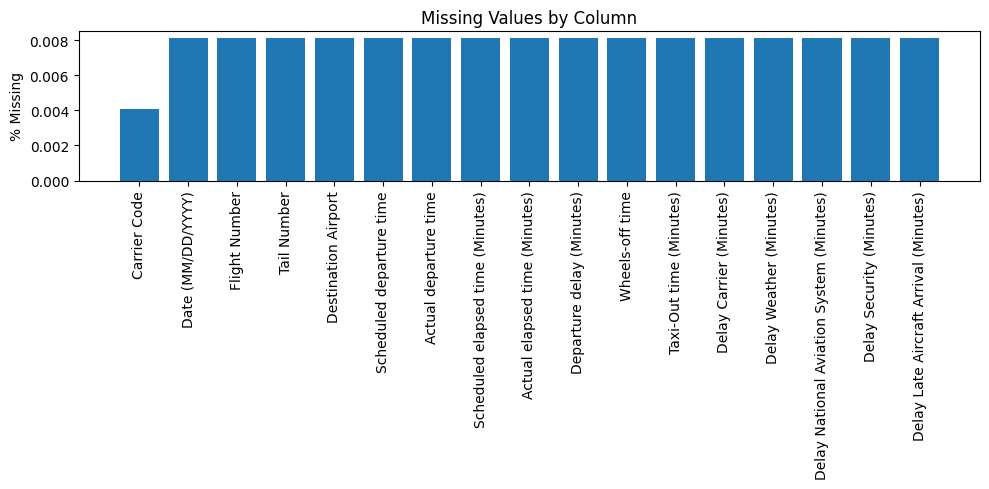

In [9]:
missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(10,5))

plt.bar(
    missing.index,
    missing["Percentage"]
)

plt.xticks(rotation=90)

plt.ylabel("% Missing")

plt.title("Missing Values by Column")

plt.tight_layout()

plt.show()

## Duplicate Records

In [10]:
duplicates = df.duplicated().sum()

print(duplicates)

0


## Summary Statistics

In [12]:
df.describe()

,Flight Number,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
count,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000,24716.000000
mean,2098.566030,176.998260,168.080596,8.474672,17.843421,6.304297,0.499231,2.988348,0.005017,1.824243
std,785.083022,56.276918,62.403450,42.273307,10.183253,33.229977,11.594175,12.874075,0.505418,13.585236
min,304.000000,62.000000,0.000000,-31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1519.000000,148.000000,136.000000,-6.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2262.000000,172.000000,165.000000,-3.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2687.000000,210.000000,203.000000,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8819.000000,541.000000,676.000000,1109.000000,129.000000,1076.000000,911.000000,367.000000,69.000000,657.000000


Average departure delay - 8.474672

Maximum delay - 1109.000000	

Average taxi-out time - 17.843421

Average elapsed time - 168.080596

## Delay Distribution

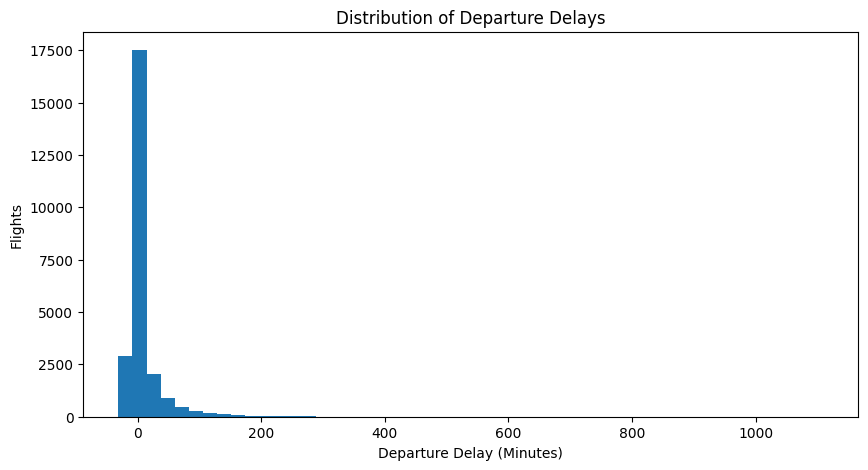

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Departure delay (Minutes)"],
    bins=50
)

plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Flights")
plt.title("Distribution of Departure Delays")

plt.show()

## Boxplot for Outliers

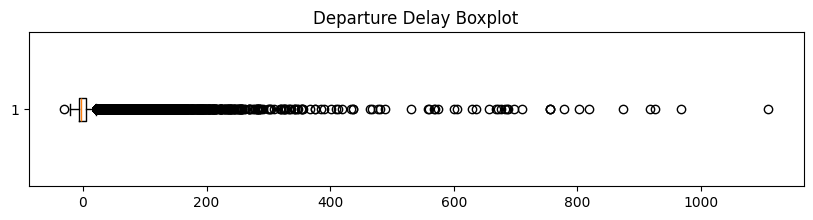

In [14]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df["Departure delay (Minutes)"].dropna(),
    vert=False
)

plt.title("Departure Delay Boxplot")

plt.show()

## Unique Values

In [25]:
df["Destination Airport"].nunique()

75

In [26]:
df["Tail Number"].nunique()

817

In [27]:
df["Flight Number"].nunique()

343

## Delay Cause Assessment

In [28]:
delay_cols = [
    "Delay Carrier (Minutes)",
    "Delay Weather (Minutes)",
    "Delay National Aviation System (Minutes)",
    "Delay Security (Minutes)",
    "Delay Late Aircraft Arrival (Minutes)"
]

df[delay_cols].sum()

Delay Carrier (Minutes)                     155817.0
Delay Weather (Minutes)                      12339.0
Delay National Aviation System (Minutes)     73860.0
Delay Security (Minutes)                       124.0
Delay Late Aircraft Arrival (Minutes)        45088.0
dtype: float64

## Destinations

In [29]:
df["Destination Airport"].value_counts().head(20)

Destination Airport
ATL    1343
LAS     898
PHX     897
MCO     862
LAX     807
LGA     763
DTW     759
DEN     703
DCA     693
SLC     680
BOS     672
SEA     645
RSW     645
DFW     578
SFO     546
TPA     533
SAN     522
IAH     491
RDU     460
BNA     456
Name: count, dtype: int64

## Initial Findings

- Dataset contains 24,718 records and 17 columns.
- No duplicate records were identified.
- Two non-data rows containing metadata were detected at the end of the file.
- Date and time fields are currently stored as text and require conversion.
- Delay metrics are already numeric and suitable for analysis after cleaning.
- The dataset provides sufficient detail to analyze operational performance by destination, aircraft, and departure delays.